<div style="
    border: 2px solid #1F4E79;
    border-radius: 12px;
    padding: 22px;
    background: linear-gradient(135deg, #F5F9FC 0%, #FFFFFF 65%, #F3F8F5 100%);
    box-shadow: 0 3px 10px rgba(0,0,0,0.10);
">

<div align="center">

# Proyecto G8 – Exoesqueleto e IA para Marcha Infantil

## Modelado, simulación y control de la interacción humano–exoesqueleto

**Desarrollo de una plataforma tecnológica integrada para la toma de decisiones basadas en datos, enfocada en la detección temprana de patologías de marcha de niños y niñas con parálisis cerebral, mediante herramientas de inteligencia artificial y terapia robótica asistida por exoesqueletos de rehabilitación de marcha.**

</div>

---

### Información institucional

| Campo | Descripción |
|---|---|
| **Entidad líder** | Universidad de Antioquia |
| **Entidades aliadas** | Universidad EAFIT, Institución Universitaria ITM, Universidad CES y Comité de Rehabilitación de Antioquia |
| **Financiación** | Cuarta Convocatoria Conjunta del G8+ en alianza con Ruta N |
| **Épica del proyecto** | Hardware y exoesqueleto |
| **Actividad asociada** | Realizar el modelado y la simulación humano–robot |
| **Entregable** | **Repositorio de Simulación: Modelos en MATLAB/Simulink y Python** |
| **Código de referencia** | IT-002 – Modelado y simulación humano–robot |
| **Responsables técnicos** | Universidad de Antioquia, Universidad EAFIT y Universidad CES |
| **Entorno computacional** | Python, MuJoCo y Google Colab |

---

## Propósito de esta colección de notebooks

Los siguientes cuadernos constituyen una línea base reproducible para estudiar el modelado dinámico, la generación de trayectorias articulares y el control de un exoesqueleto de miembro inferior antes de la fabricación e integración del prototipo físico.

| Notebook | Alcance técnico |
|---|---|
| **`Tutorial_Exoesqueleto_MuJoCo_Control_Marcha.ipynb`** | Construcción de un modelo planar simplificado de dos grados de libertad para cadera y rodilla; formulación dinámica; generación de trayectorias de marcha; control PD; control por torque computado; perturbaciones externas; evaluación de robustez; métricas de seguimiento y visualización del movimiento. |
| **`Tutorial_x2_human_mujoco_Demo_Marcha.ipynb`** | Integración con el repositorio `x2_human_mujoco`; inspección del modelo MJCF/XML; selección robusta de articulaciones y actuadores; control PD de cadera y rodilla; generación de una marcha articular periódica; renderizado de video y evaluación cuantitativa mediante MAE y RMSE. |

---

## Objetivos técnicos

1. Establecer un entorno reproducible para la simulación de sistemas humano–robot.
2. Analizar el seguimiento de trayectorias articulares de cadera y rodilla.
3. Comparar estrategias de control y su sensibilidad ante perturbaciones.
4. Documentar parámetros mecánicos, ganancias de control, restricciones y métricas.
5. Preparar la transición hacia modelos bilaterales, contacto pie–suelo, fuerzas de reacción, variabilidad antropométrica pediátrica e interacción física humano–exoesqueleto.
6. Generar señales sintéticas y resultados de simulación que apoyen el desarrollo posterior de los módulos de control, procesamiento de datos e inteligencia artificial explicable.

---

> ### Alcance y uso responsable
>
> Los modelos implementados corresponden a **pruebas de concepto computacionales y actividades de formación e investigación**. Las trayectorias, parámetros antropométricos y leyes de control utilizadas no constituyen por sí mismas una prescripción terapéutica ni una validación clínica, normativa o de seguridad.
>
> Los resultados no deben trasladarse directamente a un prototipo físico ni utilizarse con participantes sin completar previamente la revisión clínica, el análisis de riesgos, la validación en banco, los límites seguros de posición y torque, los mecanismos de parada y los avales éticos correspondientes.

---

### Principio de reproducibilidad

Cada resultado generado en estos notebooks deberá registrar, como mínimo:

- versión del notebook y fecha de ejecución;
- versión de Python, MuJoCo y dependencias;
- archivo de modelo utilizado;
- parámetros antropométricos y mecánicos;
- ganancias y límites del controlador;
- condiciones iniciales y perturbaciones;
- semillas aleatorias, cuando corresponda;
- métricas de seguimiento y evidencia gráfica;
- responsable de la ejecución y observaciones técnicas.

---

<div align="center">

**Proyecto G8 · Universidad de Antioquia · Universidad EAFIT · ITM · Universidad CES · Comité de Rehabilitación de Antioquia**

*Modelado y simulación para una rehabilitación robótica pediátrica segura, trazable y basada en evidencia.*

**Versión documental:** 0.1 &nbsp;&nbsp;|&nbsp;&nbsp; **Fecha:** julio de 2026

</div>

</div>

# Simulación y control de la marcha de un exoesqueleto de miembro inferior en MuJoCo


**Proyecto:** G8
**Tema:** Modelado, simulación y control de un exoesqueleto planar de 2 GDL  
**Herramienta:** Python + MuJoCo  

---

https://github.com/stesfazgi/rehyb_mujoco

https://github.com/NuCapybara/x2_human_mujoco

### Propósito del notebook

Este notebook desarrolla una **prueba de concepto** para simular el movimiento de una pierna de exoesqueleto en el plano sagital, inspirada en el artículo:

> Yu, L., Leto, H., & Bai, S. *Design and Gait Control of an Active Lower Limb Exoskeleton for Walking Assistance*. Machines, 2023.

El artículo plantea que el movimiento activo del exoesqueleto puede representarse mediante un **modelo de dos enlaces** con articulaciones activas en:

- **Cadera:** $\theta_{hip}$
- **Rodilla:** $\theta_{knee}$

En este tutorial construiremos:

1. Un modelo geométrico y dinámico simplificado en **MuJoCo**.
2. Trayectorias articulares periódicas de marcha.
3. Un controlador **PD articular**.
4. Una extensión con **control por torque computado** inspirado en el artículo.
5. Perturbaciones externas para estudiar robustez.
6. Gráficas de seguimiento, errores, métricas y una animación del movimiento.

---

### Resultado esperado

Al finalizar el notebook se obtendrá una simulación como prueba de concepto donde:

- La pierna del exoesqueleto sigue una trayectoria periódica.
- Se visualiza el ciclo de movimiento de cadera y rodilla.
- Se evalúa el desempeño del controlador con métricas cuantitativas.

# 1. Interpretación del problema de control

El artículo describe un exoesqueleto activo de miembro inferior orientado a asistencia de marcha. Para propósitos de control, cada pierna se aproxima mediante un sistema de **dos eslabones**:

- Eslabón 1: muslo
- Eslabón 2: pierna o *shank*

El vector de coordenadas generalizadas es:

$$
\boldsymbol{\theta}
=
\begin{bmatrix}
\theta_{hip}\\
\theta_{knee}
\end{bmatrix}
$$

y el problema de control consiste en lograr:

$$
\boldsymbol{\theta}(t) \rightarrow \boldsymbol{\theta}_d(t)
$$

donde $\boldsymbol{\theta}_d(t)$ es una trayectoria articular de referencia asociada a la marcha.

---

## 1.1. Simplificación adoptada en este tutorial

El sistema físico real incluye interacción humano-exoesqueleto, sensores de fuerza y una arquitectura jerárquica de control. Para que el proyecto sea realizable en un curso de Sistemas de Control, emplearemos una prueba de concepto:

- Simulación de **una sola pierna**.
- Movimiento en el **plano sagital**.
- La cadera permanece anclada a una base fija.
- El pie no genera locomoción real sobre el suelo; el objetivo es reproducir el **patrón articular de marcha**.
- La interacción humano-exoesqueleto se aproxima mediante **fuerzas externas perturbadoras**.

Esta decisión permite estudiar con claridad el problema de **seguimiento de trayectorias**.

# 2. Modelo dinámico de dos grados de libertad

En el artículo, la dinámica no lineal del exoesqueleto se expresa como:

$$
\mathbf{M}(\boldsymbol{\theta})\ddot{\boldsymbol{\theta}}
+
\mathbf{C}(\boldsymbol{\theta},\dot{\boldsymbol{\theta}})\dot{\boldsymbol{\theta}}
+
\mathbf{G}(\boldsymbol{\theta})
=
\boldsymbol{\tau}_{mot}
+
\boldsymbol{\tau}_{hum}
$$

donde:

- $\mathbf{M}(\boldsymbol{\theta})$: matriz de inercia.
- $\mathbf{C}(\boldsymbol{\theta},\dot{\boldsymbol{\theta}})$: términos de Coriolis y centrífugos.
- $\mathbf{G}(\boldsymbol{\theta})$: vector gravitacional.
- $\boldsymbol{\tau}_{mot}$: torque aplicado por los motores.
- $\boldsymbol{\tau}_{hum}$: torque asociado a la interacción con el usuario.

En este notebook:

- MuJoCo resuelve la dinámica rígida del sistema internamente.
- Para el control PD no necesitamos escribir explícitamente $\mathbf{M}$, $\mathbf{C}$ y $\mathbf{G}$.
- Para la extensión de torque computado, sí implementaremos las expresiones analíticas reportadas en el artículo.

---

## 2.1. Parámetros mecánicos usados

Tomamos como referencia los parámetros de simulación reportados en el artículo:

| Parámetro | Significado | Valor |
|---|---|---:|
| $m_{th}$ | masa del muslo | $3.3$ kg |
| $m_{sh}$ | masa de la pierna | $1.1$ kg |
| $l_{th}$ | longitud del muslo | $0.475$ m |
| $l_{sh}$ | longitud de la pierna | $0.45$ m |
| $l_{mt}$ | centroide del muslo respecto a la cadera | $0.36$ m |
| $l_{ms}$ | centroide de la pierna respecto a la rodilla | $0.15$ m |

---

## 2.2. Convención angular

Seguiremos una convención compatible con el modelo del artículo:

- $\theta_{hip}$ define la rotación del muslo.
- $\theta_{knee}$ define la flexión relativa de la rodilla.
- La orientación absoluta del segundo eslabón queda relacionada con el término:

$$
\theta_{hip} - \theta_{knee}
$$

Esta convención aparece en el vector gravitacional del artículo.

# 3. Trayectorias articulares de marcha

El artículo utiliza trayectorias armónicas de referencia para la simulación:

$$
\theta_{hip,d}(t)
=
60\sin(3.14t-0.609)+35
$$

$$
\theta_{knee,d}(t)
=
45\cos(3.14t)-45
$$

Estas expresiones están en **grados**. MuJoCo opera en **radianes**, por lo tanto usamos:

$$
\theta_{rad} = \theta_{deg}\frac{\pi}{180}
$$

---

## 3.1. Derivadas de las trayectorias

Para control PD y torque computado se requieren velocidades deseadas:

$$
\dot{\theta}_{hip,d}(t)
=
60(3.14)\cos(3.14t-0.609)
$$

$$
\dot{\theta}_{knee,d}(t)
=
-45(3.14)\sin(3.14t)
$$

Para torque computado también se requieren aceleraciones deseadas:

$$
\ddot{\theta}_{hip,d}(t)
=
-60(3.14)^2\sin(3.14t-0.609)
$$

$$
\ddot{\theta}_{knee,d}(t)
=
-45(3.14)^2\cos(3.14t)
$$

Todas estas cantidades se convertirán a radianes.

# 4. Controladores estudiados

## 4.1. Control PD articular

El controlador mínimo requerido para el proyecto es:

$$
\tau_i =
K_{p,i}
\left(
\theta_{d,i}-\theta_i
\right)
+
K_{d,i}
\left(
\dot{\theta}_{d,i}-\dot{\theta}_i
\right)
$$

para:

$$
i \in \{\text{hip},\text{knee}\}
$$

En forma vectorial:

$$
\boldsymbol{\tau}
=
\mathbf{K}_p \mathbf{e}
+
\mathbf{K}_d \dot{\mathbf{e}}
$$

con:

$$
\mathbf{e} =
\boldsymbol{\theta}_d-\boldsymbol{\theta}
$$

$$
\dot{\mathbf{e}} =
\dot{\boldsymbol{\theta}}_d-\dot{\boldsymbol{\theta}}
$$

---

## 4.2. Interpretación del PD

- El término proporcional corrige errores de posición.
- El término derivativo amortigua la respuesta y corrige errores de velocidad.
- Un $K_p$ demasiado bajo produce seguimiento lento.
- Un $K_p$ demasiado alto puede producir oscilaciones.
- Un $K_d$ adecuado reduce sobreimpulso y vibraciones.

---

## 4.3. Control por torque computado

El artículo propone un controlador de torque computado. Si se ignora la contribución humana $\boldsymbol{\tau}_{hum}$, una forma estándar es:

$$
\boldsymbol{\tau}
=
\mathbf{M}(\boldsymbol{\theta})
\left[
\ddot{\boldsymbol{\theta}}_d
+
\mathbf{K}_d\dot{\mathbf{e}}
+
\mathbf{K}_p\mathbf{e}
\right]
+
\mathbf{C}(\boldsymbol{\theta},\dot{\boldsymbol{\theta}})
\dot{\boldsymbol{\theta}}
+
\mathbf{G}(\boldsymbol{\theta})
$$

Bajo modelado perfecto y sin perturbaciones, la dinámica del error tiende a:

$$
\ddot{\mathbf{e}}
+
\mathbf{K}_d\dot{\mathbf{e}}
+
\mathbf{K}_p\mathbf{e}
=
\mathbf{0}
$$

Esto significa que la dinámica no lineal del robot se compensa y el error se comporta como un sistema de segundo orden diseñado por el controlador.

# 5. Instalación de dependencias en Google Colab

Ejecute la siguiente celda al inicio del notebook.  

Se instala:

- `mujoco`: motor de simulación y API oficial en Python.
- `mediapy`: visualización de videos dentro de Colab.
- Dependencias del sistema para renderizado fuera de pantalla.

> En Colab se usa renderizado *headless*. Por ello se selecciona el backend `EGL` antes de importar MuJoCo.

In [ ]:
# ============================================================
# Instalación para Google Colab
# ============================================================
!apt-get -qq update
!apt-get -qq install -y libegl1 libgl1-mesa-dev libglfw3 ffmpeg > /dev/null
!pip -q install mujoco mediapy

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 105.7 MB/s eta 0:00:00


# 6. Importación de librerías y configuración general

In [ ]:
# ============================================================
# Importaciones y configuración
# ============================================================
import os
os.environ["MUJOCO_GL"] = "egl"

import math
import numpy as np
import matplotlib.pyplot as plt
import mujoco
import mediapy as media

from dataclasses import dataclass
from pathlib import Path

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 4)

# 7. Parámetros físicos, numéricos y de control

Definimos los parámetros de la pierna del exoesqueleto.

También especificamos:

- Paso de integración.
- Tiempo total de simulación.
- Saturación máxima de torque.
- Ganancias iniciales para PD y torque computado.

Las ganancias se escogen para obtener una respuesta estable en la simulación de prueba. Los estudiantes pueden modificarlas y comparar resultados.

In [ ]:
# ============================================================
# Parámetros del exoesqueleto
# ============================================================

@dataclass
class ExoParams:
    # Parámetros mecánicos tomados como referencia del artículo
    m_th: float = 3.3       # kg
    m_sh: float = 1.1       # kg
    l_th: float = 0.475     # m
    l_sh: float = 0.450     # m
    l_mt: float = 0.360     # m
    l_ms: float = 0.150     # m
    g: float = 9.81         # m/s^2

    # Parámetros de simulación
    dt: float = 0.002       # s
    T: float = 6.0          # s
    torque_limit: float = 450.0  # N m

params = ExoParams()

# Ganancias para control PD articular
Kp_PD = np.diag([320.0, 220.0])
Kd_PD = np.diag([36.0, 24.0])

# Ganancias internas de error para torque computado
Kp_CTC = np.diag([90.0, 70.0])
Kd_CTC = np.diag([18.0, 14.0])

print(params)

ExoParams(m_th=3.3, m_sh=1.1, l_th=0.475, l_sh=0.45, l_mt=0.36, l_ms=0.15, g=9.81, dt=0.002, T=6.0, torque_limit=450.0)


# 8. Trayectorias deseadas de marcha

Implementamos:

$$
\theta_{hip,d}(t),
\quad
\theta_{knee,d}(t),
\quad
\dot{\theta}_{d}(t),
\quad
\ddot{\theta}_{d}(t)
$$

Todo se devuelve en **radianes**.

In [ ]:
# ============================================================
# Trayectorias articulares deseadas
# ============================================================

def deg2rad(x):
    return np.deg2rad(x)

def gait_reference(t: float):
    """
    Retorna:
        qd   : [theta_hip_d, theta_knee_d] en rad
        dqd  : velocidades deseadas en rad/s
        ddqd : aceleraciones deseadas en rad/s^2
    """
    w = 3.14

    # Posiciones deseadas en grados
    hip_deg = 60.0 * np.sin(w * t - 0.609) + 35.0
    knee_deg = 45.0 * np.cos(w * t) - 45.0

    # Velocidades en grados/s
    dhip_deg = 60.0 * w * np.cos(w * t - 0.609)
    dknee_deg = -45.0 * w * np.sin(w * t)

    # Aceleraciones en grados/s^2
    ddhip_deg = -60.0 * (w**2) * np.sin(w * t - 0.609)
    ddknee_deg = -45.0 * (w**2) * np.cos(w * t)

    qd = deg2rad(np.array([hip_deg, knee_deg]))
    dqd = deg2rad(np.array([dhip_deg, dknee_deg]))
    ddqd = deg2rad(np.array([ddhip_deg, ddknee_deg]))

    return qd, dqd, ddqd

# Prueba rápida
qd0, dqd0, ddqd0 = gait_reference(0.0)
print("q_d(0) [rad]   =", qd0)
print("dq_d(0) [rad/s]=", dqd0)
print("ddq_d(0)       =", ddqd0)

q_d(0) [rad]   = [0.0118 0.    ]
dq_d(0) [rad/s]= [ 2.697 -0.   ]
ddq_d(0)       = [ 5.9064 -7.7437]


# 9. Visualización previa de las trayectorias de referencia

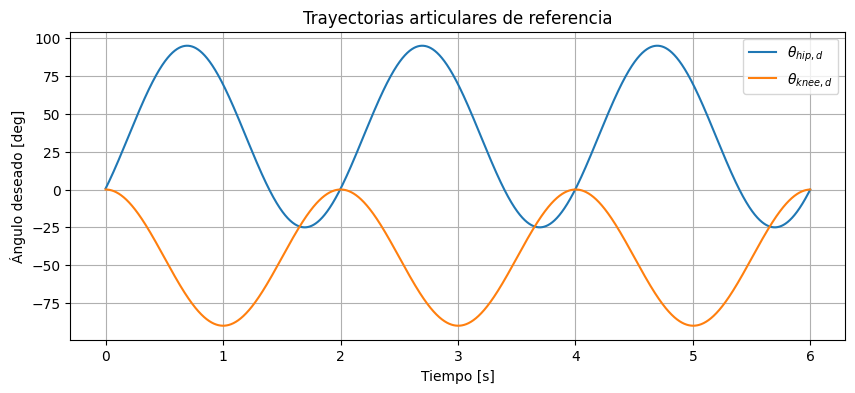

In [ ]:
# ============================================================
# Graficar trayectorias de referencia
# ============================================================

time_preview = np.arange(0.0, params.T, params.dt)
qd_preview = np.array([gait_reference(t)[0] for t in time_preview])

plt.figure()
plt.plot(time_preview, np.rad2deg(qd_preview[:, 0]), label=r"$\theta_{hip,d}$")
plt.plot(time_preview, np.rad2deg(qd_preview[:, 1]), label=r"$\theta_{knee,d}$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo deseado [deg]")
plt.title("Trayectorias articulares de referencia")
plt.grid(True)
plt.legend()
plt.show()

# 10. Modelo MuJoCo en MJCF/XML

Construimos un modelo planar con:

- Una base fija que representa la pelvis.
- Un eslabón `thigh`.
- Un eslabón `shank`.
- Dos articulaciones:
  - `hip`
  - `knee`
- Dos motores de torque:
  - `hip_motor`
  - `knee_motor`

---

## 10.1. Convención geométrica en MuJoCo

El movimiento ocurre en el plano $x$-$z$:

- El eje vertical es $z$.
- Las rotaciones articulares ocurren alrededor del eje $y$.
- En la rodilla se usa un eje negativo para que la orientación del segundo eslabón sea compatible con la convención $\theta_{hip}-\theta_{knee}$.

In [ ]:
# ============================================================
# Creación del archivo MJCF/XML
# ============================================================

I_th = (1.0 / 12.0) * params.m_th * params.l_th**2
I_sh = (1.0 / 12.0) * params.m_sh * params.l_sh**2

mjcf_model = f"""
<mujoco model="alexo_single_leg">
    <compiler angle="radian" inertiafromgeom="false"/>
    <option timestep="{params.dt}" gravity="0 0 -{params.g}" integrator="RK4"/>

    <default>
        <joint damping="0.8" armature="0.03"/>
        <geom rgba="0.65 0.65 0.65 1"/>
    </default>

    <worldbody>
        <light pos="0 0 3" dir="0 0 -1"/>

        <!-- Suelo visual -->
        <geom name="floor" type="plane" pos="0 0 -1.05" size="2 2 0.1" rgba="0.9 0.9 0.9 1"/>

        <!-- Base pélvica fija -->
        <body name="pelvis" pos="0 0 0.95">
            <geom name="pelvis_geom" type="sphere" size="0.07" rgba="0.2 0.2 0.2 1"/>

            <!-- Muslo -->
            <body name="thigh" pos="0 0 0">
                <joint name="hip" type="hinge" axis="0 1 0" range="-2.2 2.2" limited="true"/>
                <inertial pos="0 0 -{params.l_mt}" mass="{params.m_th}"
                          diaginertia="{I_th} {I_th} {I_th}"/>
                <geom name="thigh_geom" type="capsule"
                      fromto="0 0 0 0 0 -{params.l_th}"
                      size="0.045" rgba="0.15 0.45 0.80 1"/>

                <!-- Pierna -->
                <body name="shank" pos="0 0 -{params.l_th}">
                    <joint name="knee" type="hinge" axis="0 -1 0" range="-2.2 0.2" limited="true"/>
                    <inertial pos="0 0 -{params.l_ms}" mass="{params.m_sh}"
                              diaginertia="{I_sh} {I_sh} {I_sh}"/>
                    <geom name="shank_geom" type="capsule"
                          fromto="0 0 0 0 0 -{params.l_sh}"
                          size="0.040" rgba="0.85 0.35 0.20 1"/>

                    <!-- Pie visual -->
                    <body name="foot" pos="0 0 -{params.l_sh}">
                        <geom name="foot_geom" type="box"
                              pos="0.05 0 -0.02" size="0.11 0.035 0.025"
                              rgba="0.25 0.25 0.25 1"/>
                    </body>
                </body>
            </body>
        </body>
    </worldbody>

    <actuator>
        <motor name="hip_motor" joint="hip" gear="1"
               ctrllimited="true" ctrlrange="-{params.torque_limit} {params.torque_limit}"/>
        <motor name="knee_motor" joint="knee" gear="1"
               ctrllimited="true" ctrlrange="-{params.torque_limit} {params.torque_limit}"/>
    </actuator>
</mujoco>
"""

xml_path = Path("alexo_single_leg.xml")
xml_path.write_text(mjcf_model)

print(f"Modelo MJCF guardado en: {xml_path.resolve()}")
print(mjcf_model[:1500], "\n...")

Modelo MJCF guardado en: /content/alexo_single_leg.xml

<mujoco model="alexo_single_leg">
    <compiler angle="radian" inertiafromgeom="false"/>
    <option timestep="0.002" gravity="0 0 -9.81" integrator="RK4"/>

    <default>
        <joint damping="0.8" armature="0.03"/>
        <geom rgba="0.65 0.65 0.65 1"/>
    </default>

    <worldbody>
        <light pos="0 0 3" dir="0 0 -1"/>

        <!-- Suelo visual -->
        <geom name="floor" type="plane" pos="0 0 -1.05" size="2 2 0.1" rgba="0.9 0.9 0.9 1"/>

        <!-- Base pélvica fija -->
        <body name="pelvis" pos="0 0 0.95">
            <geom name="pelvis_geom" type="sphere" size="0.07" rgba="0.2 0.2 0.2 1"/>

            <!-- Muslo -->
            <body name="thigh" pos="0 0 0">
                <joint name="hip" type="hinge" axis="0 1 0" range="-2.2 2.2" limited="true"/>
                <inertial pos="0 0 -0.36" mass="3.3"
                          diaginertia="0.06204687499999999 0.06204687499999999 0.06204687499999999"/>

# 11. Cargar el modelo y verificar sus variables

MuJoCo compila el archivo XML en un objeto `MjModel` y el estado se almacena en `MjData`.

In [ ]:
# ============================================================
# Cargar modelo MuJoCo
# ============================================================

model = mujoco.MjModel.from_xml_path(str(xml_path))
data = mujoco.MjData(model)

print("Número de posiciones generalizadas nq =", model.nq)
print("Número de velocidades nv =", model.nv)
print("Número de actuadores nu =", model.nu)

hip_joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "hip")
knee_joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "knee")
thigh_body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "thigh")
shank_body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "shank")

print("ID articulación hip  =", hip_joint_id)
print("ID articulación knee =", knee_joint_id)
print("ID cuerpo thigh      =", thigh_body_id)
print("ID cuerpo shank      =", shank_body_id)

Número de posiciones generalizadas nq = 2
Número de velocidades nv = 2
Número de actuadores nu = 2
ID articulación hip  = 0
ID articulación knee = 1
ID cuerpo thigh      = 2
ID cuerpo shank      = 3


# 12. Expresiones de $\mathbf{M}$, $\mathbf{C}$ y $\mathbf{G}$ para torque computado

El artículo reporta:

$$
\mathbf{M}(\boldsymbol{\theta})=
\begin{bmatrix}
M_{11} & M_{12}\\
M_{21} & M_{22}
\end{bmatrix}
$$

con:

$$
M_{11}
=
m_{th}l_{mt}^{2}
+
\frac{1}{12}m_{th}l_{th}^{2}
+
m_{sh}
\left(
l_{th}^{2}
+
l_{ms}^{2}
+
2l_{th}l_{ms}\cos\theta_{knee}
\right)
+
\frac{1}{12}m_{sh}l_{sh}^{2}
$$

$$
M_{12}=M_{21}
=
-
m_{sh}
\left(
l_{ms}^{2}
+
l_{th}l_{ms}\cos\theta_{knee}
\right)
-
\frac{1}{12}m_{sh}l_{sh}^{2}
$$

$$
M_{22}
=
m_{sh}l_{ms}^{2}
+
\frac{1}{12}m_{sh}l_{sh}^{2}
$$

La matriz de Coriolis y centrífuga es:

$$
\mathbf{C}=
\begin{bmatrix}
C_{11} & C_{12}\\
C_{21} & C_{22}
\end{bmatrix}
$$

con:

$$
C_{11}
=
m_{sh}l_{th}l_{ms}\sin\theta_{knee}
(-2\dot{\theta}_{knee})
$$

$$
C_{12}
=
m_{sh}l_{th}l_{ms}\sin\theta_{knee}
(\dot{\theta}_{knee})
$$

$$
C_{21}
=
m_{sh}l_{th}l_{ms}\sin\theta_{knee}
(\dot{\theta}_{hip})
$$

$$
C_{22}=0
$$

Finalmente:

$$
\mathbf{G}=
\begin{bmatrix}
G_{11}\\
G_{21}
\end{bmatrix}
$$

con:

$$
G_{11}
=
(m_{th}l_{mt}+m_{sh}l_{th})g\sin\theta_{hip}
+
m_{sh}gl_{ms}\sin(\theta_{hip}-\theta_{knee})
$$

$$
G_{21}
=
-
m_{sh}gl_{ms}\sin(\theta_{hip}-\theta_{knee})
$$

In [ ]:
# ============================================================
# Dinámica analítica del modelo de dos enlaces
# ============================================================

def mass_matrix_article(q, p: ExoParams):
    th_h, th_k = q

    M11 = (
        p.m_th * p.l_mt**2
        + (1.0 / 12.0) * p.m_th * p.l_th**2
        + p.m_sh * (
            p.l_th**2
            + p.l_ms**2
            + 2.0 * p.l_th * p.l_ms * np.cos(th_k)
        )
        + (1.0 / 12.0) * p.m_sh * p.l_sh**2
    )

    M12 = (
        -p.m_sh * (p.l_ms**2 + p.l_th * p.l_ms * np.cos(th_k))
        - (1.0 / 12.0) * p.m_sh * p.l_sh**2
    )

    M22 = (
        p.m_sh * p.l_ms**2
        + (1.0 / 12.0) * p.m_sh * p.l_sh**2
    )

    return np.array([
        [M11, M12],
        [M12, M22]
    ])


def coriolis_matrix_article(q, dq, p: ExoParams):
    th_h, th_k = q
    dth_h, dth_k = dq

    common = p.m_sh * p.l_th * p.l_ms * np.sin(th_k)

    C11 = common * (-2.0 * dth_k)
    C12 = common * dth_k
    C21 = common * dth_h
    C22 = 0.0

    return np.array([
        [C11, C12],
        [C21, C22]
    ])


def gravity_vector_article(q, p: ExoParams):
    th_h, th_k = q

    G11 = (
        (p.m_th * p.l_mt + p.m_sh * p.l_th) * p.g * np.sin(th_h)
        + p.m_sh * p.g * p.l_ms * np.sin(th_h - th_k)
    )

    G21 = (
        -p.m_sh * p.g * p.l_ms * np.sin(th_h - th_k)
    )

    return np.array([G11, G21])


# Prueba numérica
q_test = np.array([0.2, -0.4])
dq_test = np.array([0.1, -0.2])

print("M(q) =\n", mass_matrix_article(q_test, params))
print("C(q,dq) =\n", coriolis_matrix_article(q_test, dq_test, params))
print("G(q) =", gravity_vector_article(q_test, params))

M(q) =
 [[ 0.9256 -0.1155]
 [-0.1155  0.0433]]
C(q,dq) =
 [[-0.0122  0.0061]
 [-0.0031  0.    ]]
G(q) = [ 4.2476 -0.914 ]


# 13. Leyes de control en código

In [ ]:
# ============================================================
# Controladores
# ============================================================

def pd_controller(q, dq, qd, dqd, Kp=Kp_PD, Kd=Kd_PD):
    """
    Control PD articular.
    """
    e = qd - q
    de = dqd - dq
    tau = Kp @ e + Kd @ de
    return tau


def computed_torque_controller(q, dq, qd, dqd, ddqd, p: ExoParams,
                               Kp=Kp_CTC, Kd=Kd_CTC):
    """
    Control por torque computado inspirado en el artículo.
    """
    e = qd - q
    de = dqd - dq

    M = mass_matrix_article(q, p)
    C = coriolis_matrix_article(q, dq, p)
    G = gravity_vector_article(q, p)

    v = ddqd + Kd @ de + Kp @ e
    tau = M @ v + C @ dq + G

    return tau

# 14. Perturbaciones externas

El artículo analiza fuerzas periódicas y aleatorias aplicadas a muslo y pierna. En esta simulación implementamos una aproximación:

$$
F_t(t)=50\cos(\pi t)-50+f_t
$$

$$
F_s(t)=40\cos(\pi t)-40+f_s
$$

donde $f_t$ y $f_s$ son perturbaciones aleatorias.

En MuJoCo aplicamos estas fuerzas como fuerzas externas sobre los cuerpos `thigh` y `shank`.

> Para activar o desactivar perturbaciones, se modifica el parámetro `disturbance_level`.

In [ ]:
# ============================================================
# Fuerzas externas perturbadoras
# ============================================================

def apply_external_disturbance(data, thigh_id, shank_id, t, disturbance_level=0.0, rng=None):
    """
    Aplica fuerzas externas aproximadas sobre muslo y pierna.

    disturbance_level:
        0.0  -> sin perturbación
        10.0 -> ruido aleatorio aproximadamente entre 0 y 10 N
        20.0 -> ruido aleatorio aproximadamente entre 0 y 20 N
        30.0 -> ruido aleatorio aproximadamente entre 0 y 30 N
    """
    data.xfrc_applied[:] = 0.0

    if disturbance_level <= 0.0:
        return

    if rng is None:
        rng = np.random.default_rng(0)

    ft = rng.uniform(0.0, disturbance_level)
    fs = rng.uniform(0.0, disturbance_level)

    Ft = 50.0 * np.cos(np.pi * t) - 50.0 + ft
    Fs = 40.0 * np.cos(np.pi * t) - 40.0 + fs

    # Fuerza en dirección x sobre el centro de masa de cada cuerpo
    data.xfrc_applied[thigh_id, 0] = Ft
    data.xfrc_applied[shank_id, 0] = Fs

# 15. Función general de simulación

La siguiente función:

1. Reinicia el sistema.
2. Evalúa la trayectoria deseada.
3. Calcula el torque de control.
4. Aplica saturación.
5. Inserta perturbaciones externas.
6. Avanza la simulación en MuJoCo.
7. Guarda variables para análisis.

El parámetro `controller` puede ser:

- `"PD"`
- `"CTC"`

In [ ]:
# ============================================================
# Simulación general
# ============================================================

def simulate_exoskeleton(controller="PD",
                         disturbance_level=0.0,
                         render=False,
                         fps=30,
                         seed=123):
    """
    Simula el exoesqueleto planar.

    Parameters
    ----------
    controller : str
        "PD" o "CTC".
    disturbance_level : float
        Nivel de perturbación aleatoria [N].
    render : bool
        Si True, captura frames para video.
    fps : int
        Fotogramas por segundo del video.
    seed : int
        Semilla para perturbaciones.

    Returns
    -------
    results : dict
        Series temporales y métricas.
    frames : list
        Frames del video si render=True.
    """

    sim_model = mujoco.MjModel.from_xml_path(str(xml_path))
    sim_data = mujoco.MjData(sim_model)

    # IDs en el modelo local
    local_thigh_id = mujoco.mj_name2id(sim_model, mujoco.mjtObj.mjOBJ_BODY, "thigh")
    local_shank_id = mujoco.mj_name2id(sim_model, mujoco.mjtObj.mjOBJ_BODY, "shank")

    rng = np.random.default_rng(seed)

    # Estado inicial cercano a la trayectoria deseada inicial
    qd0, dqd0, _ = gait_reference(0.0)
    sim_data.qpos[:] = qd0
    sim_data.qvel[:] = dqd0
    mujoco.mj_forward(sim_model, sim_data)

    time = np.arange(0.0, params.T, params.dt)
    n_steps = len(time)

    q_hist = np.zeros((n_steps, 2))
    dq_hist = np.zeros((n_steps, 2))
    qd_hist = np.zeros((n_steps, 2))
    dqd_hist = np.zeros((n_steps, 2))
    tau_hist = np.zeros((n_steps, 2))
    err_hist = np.zeros((n_steps, 2))

    frames = []
    renderer = None
    render_every = max(1, int(round(1.0 / (fps * params.dt))))

    if render:
        renderer = mujoco.Renderer(sim_model, height=480, width=640)
        camera = mujoco.MjvCamera()
        camera.azimuth = 90
        camera.elevation = 0
        camera.distance = 1.55
        camera.lookat[:] = np.array([0.0, 0.0, 0.35])

    for k, t in enumerate(time):
        q = sim_data.qpos[:2].copy()
        dq = sim_data.qvel[:2].copy()

        qd, dqd, ddqd = gait_reference(t)

        if controller.upper() == "PD":
            tau = pd_controller(q, dq, qd, dqd)
        elif controller.upper() == "CTC":
            tau = computed_torque_controller(q, dq, qd, dqd, ddqd, params)
        else:
            raise ValueError("controller debe ser 'PD' o 'CTC'.")

        # Saturación de torque
        tau = np.clip(tau, -params.torque_limit, params.torque_limit)

        # Aplicar control
        sim_data.ctrl[:] = tau

        # Perturbaciones externas
        apply_external_disturbance(
            sim_data,
            local_thigh_id,
            local_shank_id,
            t,
            disturbance_level=disturbance_level,
            rng=rng
        )

        # Guardar antes de avanzar
        q_hist[k] = q
        dq_hist[k] = dq
        qd_hist[k] = qd
        dqd_hist[k] = dqd
        tau_hist[k] = tau
        err_hist[k] = qd - q

        # Avanzar simulación
        mujoco.mj_step(sim_model, sim_data)

        # Capturar frame
        if render and (k % render_every == 0):
            renderer.update_scene(sim_data, camera=camera)
            frames.append(renderer.render())

    if renderer is not None:
        renderer.close()

    # Métricas en grados
    err_deg = np.rad2deg(err_hist)
    mae_deg = np.mean(np.abs(err_deg), axis=0)
    rmse_deg = np.sqrt(np.mean(err_deg**2, axis=0))

    results = {
        "time": time,
        "q": q_hist,
        "dq": dq_hist,
        "qd": qd_hist,
        "dqd": dqd_hist,
        "tau": tau_hist,
        "error": err_hist,
        "mae_deg": mae_deg,
        "rmse_deg": rmse_deg,
        "controller": controller,
        "disturbance_level": disturbance_level,
    }

    return results, frames

# 16. Simulación base: control PD sin perturbaciones

In [ ]:
# ============================================================
# Ejecutar control PD sin perturbaciones
# ============================================================

results_pd, _ = simulate_exoskeleton(
    controller="PD",
    disturbance_level=0.0,
    render=False
)

print("Métricas de seguimiento - PD sin perturbación")
print(f"MAE cadera  = {results_pd['mae_deg'][0]:.3f} deg")
print(f"MAE rodilla = {results_pd['mae_deg'][1]:.3f} deg")
print(f"RMSE cadera = {results_pd['rmse_deg'][0]:.3f} deg")
print(f"RMSE rodilla= {results_pd['rmse_deg'][1]:.3f} deg")

Métricas de seguimiento - PD sin perturbación
MAE cadera  = 1.350 deg
MAE rodilla = 0.286 deg
RMSE cadera = 1.488 deg
RMSE rodilla= 0.387 deg


# 17. Gráficas de seguimiento para control PD

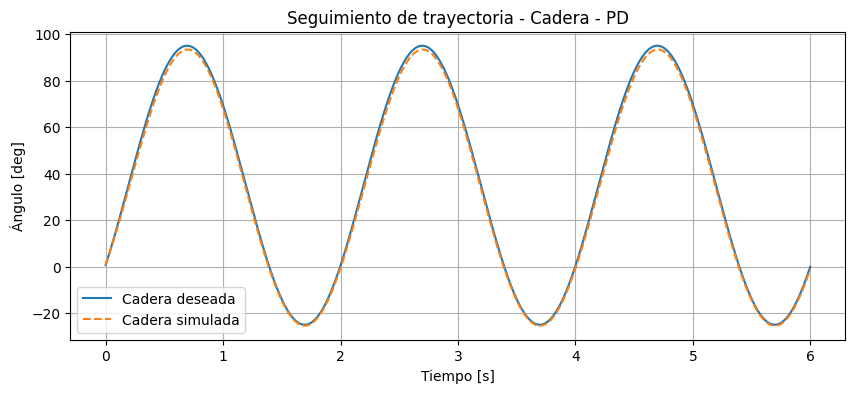

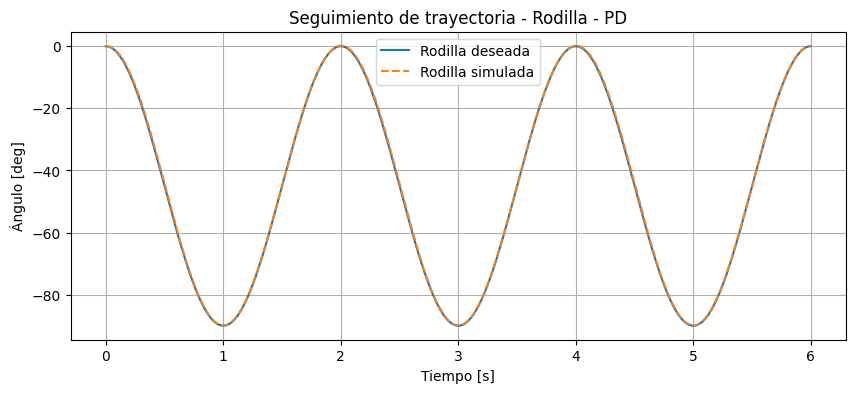

In [ ]:
# ============================================================
# Gráficas: trayectoria real vs deseada
# ============================================================

t = results_pd["time"]
q_deg = np.rad2deg(results_pd["q"])
qd_deg = np.rad2deg(results_pd["qd"])

plt.figure()
plt.plot(t, qd_deg[:, 0], label="Cadera deseada")
plt.plot(t, q_deg[:, 0], "--", label="Cadera simulada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [deg]")
plt.title("Seguimiento de trayectoria - Cadera - PD")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, qd_deg[:, 1], label="Rodilla deseada")
plt.plot(t, q_deg[:, 1], "--", label="Rodilla simulada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [deg]")
plt.title("Seguimiento de trayectoria - Rodilla - PD")
plt.grid(True)
plt.legend()
plt.show()

# 18. Errores de seguimiento y torque de control

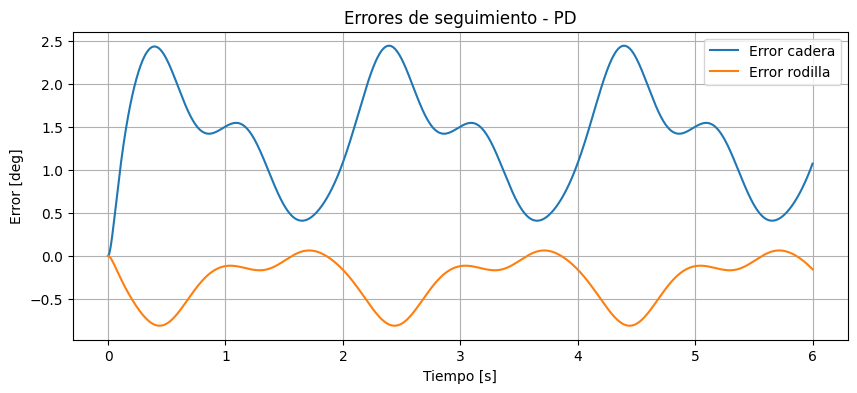

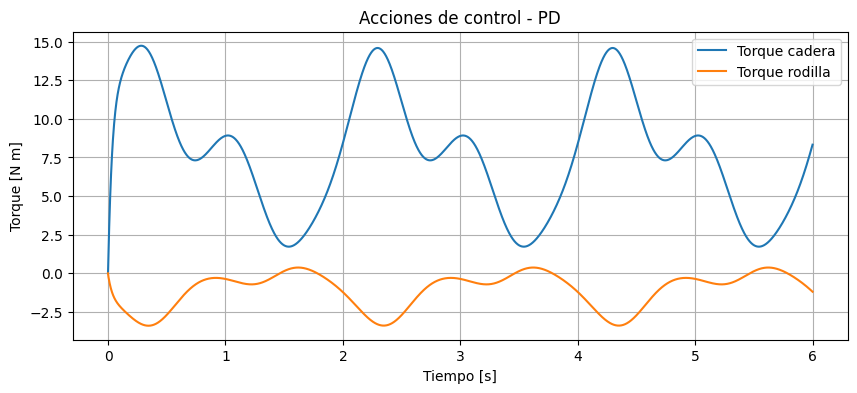

In [ ]:
# ============================================================
# Errores y torques
# ============================================================

error_deg = np.rad2deg(results_pd["error"])
tau = results_pd["tau"]

plt.figure()
plt.plot(t, error_deg[:, 0], label="Error cadera")
plt.plot(t, error_deg[:, 1], label="Error rodilla")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error [deg]")
plt.title("Errores de seguimiento - PD")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, tau[:, 0], label="Torque cadera")
plt.plot(t, tau[:, 1], label="Torque rodilla")
plt.xlabel("Tiempo [s]")
plt.ylabel("Torque [N m]")
plt.title("Acciones de control - PD")
plt.grid(True)
plt.legend()
plt.show()

# 19. Animación de la marcha articular simulada

La siguiente celda vuelve a ejecutar la simulación con renderizado activo y genera un video dentro de Colab.

In [ ]:
# ============================================================
# Simulación con video
# ============================================================

results_pd_video, frames_pd = simulate_exoskeleton(
    controller="PD",
    disturbance_level=0.0,
    render=True,
    fps=30
)

media.show_video(frames_pd, fps=30)

This browser does not support the video tag.


# 20. Robustez: PD con perturbaciones externas

Ahora repetimos la simulación añadiendo perturbaciones de nivel $10$ N.

In [ ]:
# ============================================================
# PD con perturbaciones
# ============================================================

results_pd_dist, _ = simulate_exoskeleton(
    controller="PD",
    disturbance_level=10.0,
    render=False,
    seed=2026
)

print("Métricas de seguimiento - PD con perturbación de 10 N")
print(f"MAE cadera  = {results_pd_dist['mae_deg'][0]:.3f} deg")
print(f"MAE rodilla = {results_pd_dist['mae_deg'][1]:.3f} deg")
print(f"RMSE cadera = {results_pd_dist['rmse_deg'][0]:.3f} deg")
print(f"RMSE rodilla= {results_pd_dist['rmse_deg'][1]:.3f} deg")

Métricas de seguimiento - PD con perturbación de 10 N
MAE cadera  = 2.874 deg
MAE rodilla = 1.178 deg
RMSE cadera = 3.518 deg
RMSE rodilla= 1.471 deg


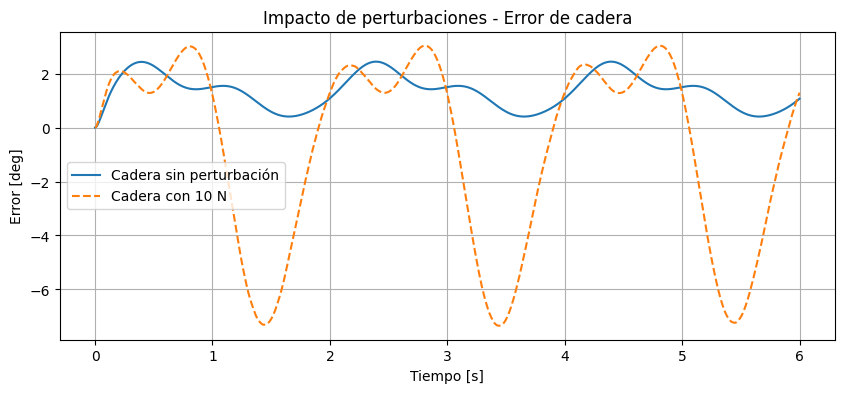

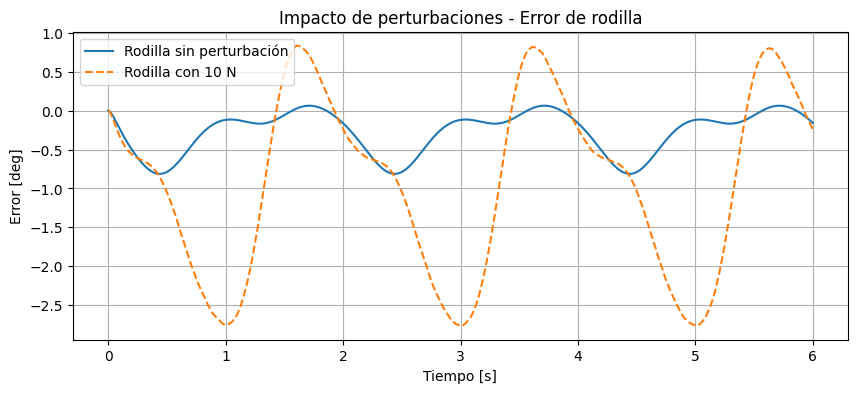

In [ ]:
# ============================================================
# Comparación del error: sin perturbación vs con perturbación
# ============================================================

err_pd = np.rad2deg(results_pd["error"])
err_pd_dist = np.rad2deg(results_pd_dist["error"])

plt.figure()
plt.plot(t, err_pd[:, 0], label="Cadera sin perturbación")
plt.plot(t, err_pd_dist[:, 0], "--", label="Cadera con 10 N")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error [deg]")
plt.title("Impacto de perturbaciones - Error de cadera")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, err_pd[:, 1], label="Rodilla sin perturbación")
plt.plot(t, err_pd_dist[:, 1], "--", label="Rodilla con 10 N")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error [deg]")
plt.title("Impacto de perturbaciones - Error de rodilla")
plt.grid(True)
plt.legend()
plt.show()

# 21. Extensión avanzada: torque computado

En esta sección se simula un controlador dinámico inspirado en el artículo.

Recordemos:

$$
\boldsymbol{\tau}
=
\mathbf{M}(\boldsymbol{\theta})
\left[
\ddot{\boldsymbol{\theta}}_d
+
\mathbf{K}_d\dot{\mathbf{e}}
+
\mathbf{K}_p\mathbf{e}
\right]
+
\mathbf{C}(\boldsymbol{\theta},\dot{\boldsymbol{\theta}})
\dot{\boldsymbol{\theta}}
+
\mathbf{G}(\boldsymbol{\theta})
$$

> Esta implementación es una extensión formativa. Debido a que MuJoCo integra su propia dinámica y nuestro modelo geométrico es simplificado, los resultados no deben interpretarse como una reproducción exacta del artículo, sino como una comparación pedagógica entre control cinemático local y compensación dinámica aproximada.

In [ ]:
# ============================================================
# Control por torque computado sin perturbaciones
# ============================================================

results_ctc, _ = simulate_exoskeleton(
    controller="CTC",
    disturbance_level=0.0,
    render=False
)

print("Métricas de seguimiento - Torque computado")
print(f"MAE cadera  = {results_ctc['mae_deg'][0]:.3f} deg")
print(f"MAE rodilla = {results_ctc['mae_deg'][1]:.3f} deg")
print(f"RMSE cadera = {results_ctc['rmse_deg'][0]:.3f} deg")
print(f"RMSE rodilla= {results_ctc['rmse_deg'][1]:.3f} deg")

Métricas de seguimiento - Torque computado
MAE cadera  = 1.656 deg
MAE rodilla = 15.759 deg
RMSE cadera = 1.880 deg
RMSE rodilla= 17.805 deg


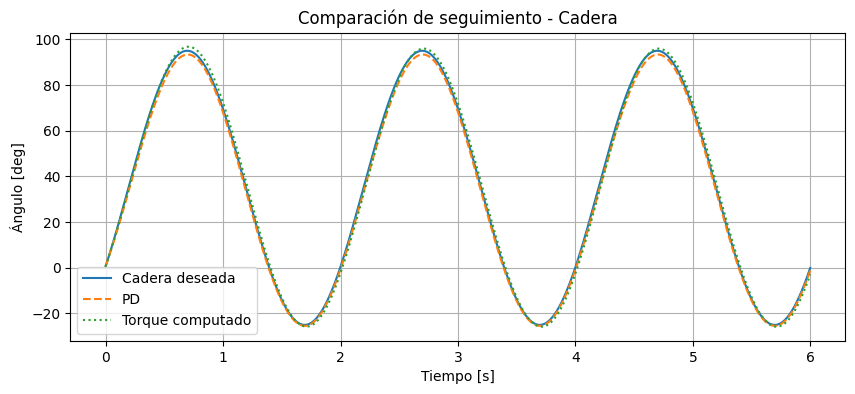

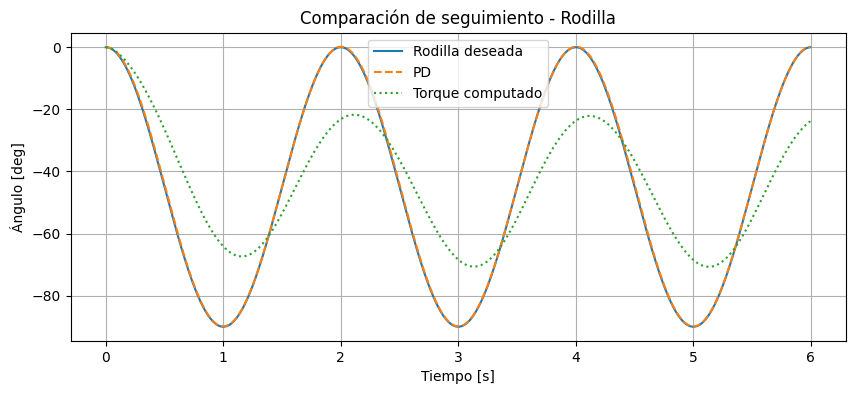

In [ ]:
# ============================================================
# Comparación PD vs torque computado
# ============================================================

t_ctc = results_ctc["time"]
q_ctc_deg = np.rad2deg(results_ctc["q"])
qd_ctc_deg = np.rad2deg(results_ctc["qd"])

plt.figure()
plt.plot(t, qd_deg[:, 0], label="Cadera deseada")
plt.plot(t, q_deg[:, 0], "--", label="PD")
plt.plot(t_ctc, q_ctc_deg[:, 0], ":", label="Torque computado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [deg]")
plt.title("Comparación de seguimiento - Cadera")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, qd_deg[:, 1], label="Rodilla deseada")
plt.plot(t, q_deg[:, 1], "--", label="PD")
plt.plot(t_ctc, q_ctc_deg[:, 1], ":", label="Torque computado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [deg]")
plt.title("Comparación de seguimiento - Rodilla")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# ============================================================
# Tabla resumen de métricas
# ============================================================

summary = {
    "PD sin perturbación": results_pd,
    "PD con 10 N": results_pd_dist,
    "CTC sin perturbación": results_ctc,
}

print(f"{'Caso':<25} {'MAE hip [deg]':>15} {'MAE knee [deg]':>17} {'RMSE hip [deg]':>17} {'RMSE knee [deg]':>19}")
print("-" * 100)

for name, res in summary.items():
    print(
        f"{name:<25}"
        f"{res['mae_deg'][0]:>15.3f}"
        f"{res['mae_deg'][1]:>17.3f}"
        f"{res['rmse_deg'][0]:>17.3f}"
        f"{res['rmse_deg'][1]:>19.3f}"
    )

Caso                        MAE hip [deg]    MAE knee [deg]    RMSE hip [deg]     RMSE knee [deg]
----------------------------------------------------------------------------------------------------
PD sin perturbación                1.350            0.286            1.488              0.387
PD con 10 N                        2.874            1.178            3.518              1.471
CTC sin perturbación               1.656           15.759            1.880             17.805


# 22. Actividades sugeridas para los estudiantes

## Actividad 1. Sintonía del PD

Modifique:

```python
Kp_PD = np.diag([Kp_hip, Kp_knee])
Kd_PD = np.diag([Kd_hip, Kd_knee])
```

y responda:

1. ¿Qué ocurre si se disminuye $K_p$?
2. ¿Qué ocurre si se incrementa excesivamente $K_p$?
3. ¿Cómo cambia el comportamiento al aumentar $K_d$?
4. ¿La rodilla y la cadera requieren las mismas ganancias?

---

## Actividad 2. Análisis de robustez

Ejecute simulaciones con:

- `disturbance_level = 0`
- `disturbance_level = 10`
- `disturbance_level = 20`
- `disturbance_level = 30`

Compare:

- MAE
- RMSE
- Torque máximo
- Error máximo

---

## Actividad 3. Comparación de controladores

Compare:

- Control PD
- Torque computado aproximado

Discuta:

1. ¿Cuál sigue mejor la trayectoria?
2. ¿Cuál requiere mayor esfuerzo de control?
3. ¿Cuál parece más sensible a perturbaciones?
4. ¿Qué limitaciones tiene la implementación de torque computado en una simulación simplificada?

---

## Actividad 4. Extensión opcional

Implemente una o más de las siguientes mejoras:

- Modelo bilateral con dos piernas en contrafase.
- Inclusión de una articulación pasiva de tobillo.
- Contacto del pie con el suelo.
- Trayectorias de marcha tomadas de datos reales.
- Control PID o LQR linealizado alrededor de un punto de operación.

# 23. Conclusiones del tutorial

Este notebook muestra que un exoesqueleto de miembro inferior puede abordarse, en una primera etapa, como un problema de:

1. **Modelado de un sistema mecánico articulado**.
2. **Generación de trayectorias periódicas**.
3. **Diseño de un controlador de seguimiento**.
4. **Evaluación de robustez frente a perturbaciones**.

La prueba de concepto desarrollada no reproduce todos los detalles del sistema ALEXO, pero sí conserva la idea central del artículo:

> Controlar las articulaciones de cadera y rodilla para reproducir un patrón de marcha prescrito.

A partir de esta base, el estudiante puede avanzar hacia modelos más realistas, incorporación de interacción humano-robot y estrategias de control más sofisticadas.